<a href="https://colab.research.google.com/github/Yash-Agarwal-4a5h/cei-assignments-yash-agarwal-jecrc-college/blob/main/week5_yash_agarwal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

I0000 00:00:1782059517.539959    2693 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782059517.540775    2693 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782059517.603645    2693 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782059519.419872    2693 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782059519.420392    2693 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a small **built-in sample corpus** focused on deep learning / NLP concepts, so the model has a
consistent theme to learn from and generated text stays topical.

You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF-extracted text

> 💡 **Why does corpus size matter?** With very little text, the model can only memorize a handful of
> sentence patterns — it can't generalize. We use a slightly larger (but still beginner-friendly) corpus
> here so RNN vs LSTM vs GRU differences are easier to see.

In [ ]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
neural networks learn patterns from large amounts of data
artificial intelligence is changing the way we live and work
machine learning models require data to learn patterns
recurrent neural networks process sequences one step at a time
vanilla rnn struggles to remember long term dependencies
lstm uses gates to control the flow of information
gru combines the forget and input gates into a single update gate
deep learning powers modern speech recognition systems
neural networks can learn to translate one language into another
text generation is a popular application of deep learning
language models predict the next word based on previous context
training deep learning models requires large datasets and computation
gated architectures solve the vanishing gradient problem in rnns
attention mechanisms help models focus on relevant parts of input
"""

print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
neural networks learn patterns from large amounts of data
artificial intelligence is changing the way we live and work
machine learning models require data to learn patterns
recurrent neural networks process sequences one step at a time
vanilla rnn struggles to remember long term dependencies
lstm uses gates to control the flow of information
gru combines the forget and input gates into a single update gate
deep learning powers modern speech recognition systems
neural networks can learn to translate one language into another
text generation is a popular application of deep learning
language models predict the next word based on previous context
training deep learning models requires large datasets an

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences** for next-word prediction.

For example, the line `"deep learning is transforming artificial intelligence"` becomes training pairs like:

| Input (X) | Target (y) |
|---|---|
| deep learning | is |
| deep learning is | transforming |
| deep learning is transforming | artificial |
| deep learning is transforming artificial | intelligence |

This is exactly how language models are framed: **given previous words, predict the next one.**

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.strip().split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Total training sequences:", len(input_sequences))
print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 105
Total training sequences: 151
X shape: (151, 11)
y shape: (151,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model. At each timestep $t$, it combines the current input with the
previous hidden state:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

It struggles with long-term dependencies because of the **vanishing gradient problem**: during
backpropagation through time, gradients are repeatedly multiplied by the same weight matrix $W_h$. If
the largest eigenvalue of $W_h$ is less than 1, gradients shrink exponentially as they flow backward —
so the network effectively "forgets" information from many steps ago.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_model.summary()

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed | final accuracy:", round(rnn_history.history['accuracy'][-1], 4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1782059521.339137    2693 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Vanilla RNN training completed | final accuracy: 0.9536


# 🔒 Model 2: LSTM
LSTM (Long Short-Term Memory) adds a separate **cell state** $c_t$ — a kind of conveyor belt that
information can flow along mostly unchanged — controlled by three gates:

- **Forget gate** $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ — what to throw away from cell state
- **Input gate** $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ — what new info to store
- **Output gate** $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ — what part of cell state to expose as output

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \qquad h_t = o_t \odot \tanh(c_t)$$

Because $c_t$ updates **additively** (not through repeated matrix multiplication like vanilla RNN),
gradients can flow backward through many timesteps without vanishing — this is why LSTM is much better
at capturing long-range dependencies.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model.summary()

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed | final accuracy:", round(lstm_history.history['accuracy'][-1], 4))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

LSTM training completed | final accuracy: 0.7285


# ⚡ Model 3: GRU
GRU (Gated Recurrent Unit) simplifies LSTM by merging the cell state and hidden state into one, and
using only **two gates**:

- **Update gate** $z_t = \sigma(W_z [h_{t-1}, x_t] + b_z)$ — balances old vs new information
- **Reset gate** $r_t = \sigma(W_r [h_{t-1}, x_t] + b_r)$ — controls how much past info to forget

$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

Fewer gates means **fewer parameters** than LSTM, so GRU trains faster and often needs less data to
generalize — while still solving the vanishing gradient problem via the same additive-update idea.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_model.summary()

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed | final accuracy:", round(gru_history.history['accuracy'][-1], 4))

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

GRU training completed | final accuracy: 0.947


## 📉 Compare Training Loss & Accuracy

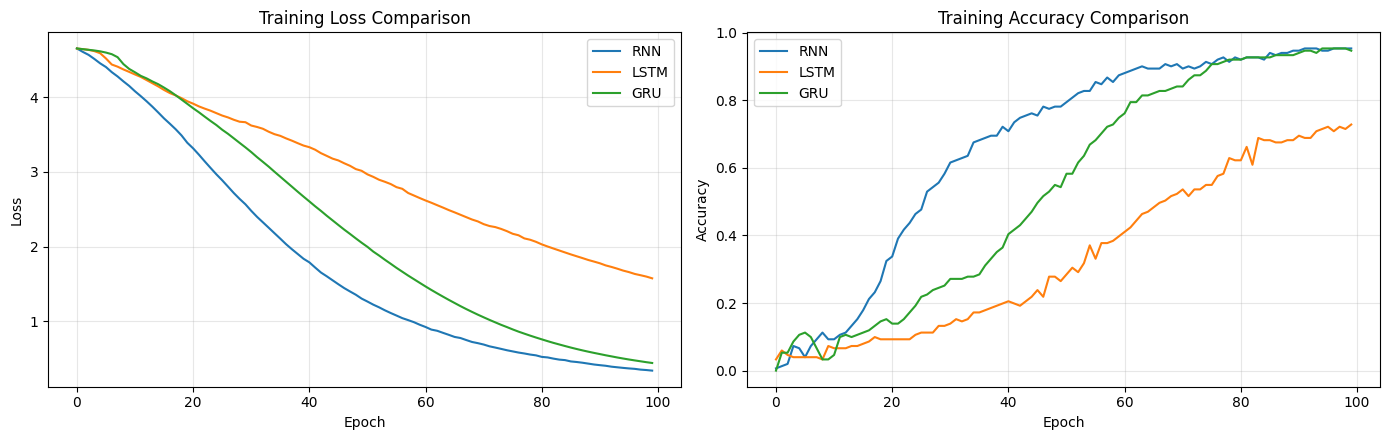

Model       Params    Final Loss   Final Acc
RNN         16,393        0.3370      0.9536
LSTM        35,017        1.5740      0.7285
GRU         29,001        0.4393      0.9470


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(rnn_history.history['loss'], label='RNN')
axes[0].plot(lstm_history.history['loss'], label='LSTM')
axes[0].plot(gru_history.history['loss'], label='GRU')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss Comparison")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rnn_history.history['accuracy'], label='RNN')
axes[1].plot(lstm_history.history['accuracy'], label='LSTM')
axes[1].plot(gru_history.history['accuracy'], label='GRU')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy Comparison")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'Model':<6}{'Params':>12}{'Final Loss':>14}{'Final Acc':>12}")
for name, model, hist in [('RNN', rnn_model, rnn_history),
                           ('LSTM', lstm_model, lstm_history),
                           ('GRU', gru_model, gru_history)]:
    print(f"{name:<6}{model.count_params():>12,}{hist.history['loss'][-1]:>14.4f}{hist.history['accuracy'][-1]:>12.4f}")

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence (**greedy decoding**: always
pick the highest-probability word). We also add a **temperature-sampling** variant below — instead of
always taking the most likely word, it samples from the probability distribution, which produces more
varied (and sometimes more interesting) text.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    """Greedy decoding: always picks the single most probable next word."""
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text


def generate_text_sampled(model, seed_text, next_words=5, temperature=0.8):
    """Temperature sampling: samples from the predicted distribution instead of
    always taking the argmax, giving more varied generations.
    Lower temperature -> more conservative/repetitive; higher -> more random."""
    index_to_word = {index: word for word, index in tokenizer.word_index.items()}

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        preds = model.predict(token_list, verbose=0)[0].astype('float64')

        # apply temperature
        preds = np.log(preds + 1e-9) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        predicted_index = np.random.choice(len(preds), p=preds)
        output_word = index_to_word.get(predicted_index, "")
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
seed_phrases = ["deep learning", "neural networks", "lstm helps", "gru is"]

print("=== Greedy decoding (deterministic) ===")
for seed in seed_phrases:
    print(f"RNN  : {generate_text(rnn_model, seed, 6)}")
    print(f"LSTM : {generate_text(lstm_model, seed, 6)}")
    print(f"GRU  : {generate_text(gru_model, seed, 6)}")
    print()

print("=== Temperature sampling (temperature=0.7, more variety) ===")
for seed in seed_phrases[:2]:
    print(f"LSTM : {generate_text_sampled(lstm_model, seed, 6, temperature=0.7)}")
    print(f"GRU  : {generate_text_sampled(gru_model, seed, 6, temperature=0.7)}")
    print()

=== Greedy decoding (deterministic) ===


RNN  : deep learning models can generate meaningful sentences of


LSTM : deep learning models models the next word on


GRU  : deep learning models can generate meaningful sentences sentences



RNN  : neural networks can learn to translate one language


...

GRU  : gru is faster and simpler than lstm lstm

=== Temperature sampling (temperature=0.7, more variety) ===


LSTM : deep learning models models useful next datasets sentences


GRU  : deep learning models can generate meaningful sentences networks



LSTM : neural networks the changing of amounts computation data


GRU  : neural networks learn patterns large amounts of data



# 📚 Student Learning Tasks

### ✅ Beginner Tasks
1. **Replace corpus with your own paragraph** — swap the `corpus` string in the cell above with any text of your choice (song lyrics, a paragraph from a book, your notes). Re-run the tokenization cell onward.
2. **Increase embedding dimension** — change `Embedding(total_words, 32, ...)` to `Embedding(total_words, 64, ...)` or `128`. Larger embeddings can capture richer word relationships but need more data to avoid overfitting.
3. **Increase epochs to 200** — change `epochs=100` to `epochs=200` in each `.fit()` call. Watch whether loss keeps decreasing or plateaus (a sign of overfitting on this small corpus).
4. **Change hidden units 64 → 128** — change `SimpleRNN(64)`, `LSTM(64)`, `GRU(64)` to `128`. This increases model capacity (and parameter count — check with `.summary()`).
5. **Generate 10 words instead of 5** — call `generate_text(model, seed_text, next_words=10)`.

### 🚀 Intermediate / Stretch Tasks (try these next!)
6. **Compare parameter counts** — use `model.count_params()` (already printed in the comparison table above) to see how LSTM has roughly 4× the recurrent parameters of vanilla RNN, and GRU about 3×. This is *why* GRU trains faster per epoch.
7. **Try stacking layers** — e.g. `LSTM(64, return_sequences=True)` followed by another `LSTM(64)`. Deeper models can capture more complex patterns but are harder to train on small corpora.
8. **Add Dropout** — insert `Dropout(0.2)` after the recurrent layer to reduce overfitting, especially useful once you increase epochs/units.
9. **Experiment with temperature sampling** — try `generate_text_sampled(model, seed, temperature=0.3)` (conservative) vs `temperature=1.2` (more random/creative) and compare outputs.
10. **Plot embeddings** — extract `model.layers[0].get_weights()[0]` and use PCA/t-SNE to visualize which words the model considers similar.

# ✅ Conclusion

- **Vanilla RNN** learns short patterns reasonably well on small data, but its hidden state update
  multiplies the same weight matrix at every timestep, causing gradients to vanish over long sequences
  — it struggles with long-range grammatical dependencies.
- **LSTM** introduces a separate cell state with additive updates controlled by forget/input/output
  gates, letting gradients flow over many timesteps. This makes it better at long-range dependencies,
  at the cost of more parameters and (often) slower convergence per epoch.
- **GRU** merges LSTM's cell and hidden states and uses only two gates (update + reset). It usually
  matches LSTM's quality with fewer parameters and faster training — a great default choice when
  compute or data is limited.
- **Practical takeaway:** for short sequences and tiny datasets, a vanilla RNN can be competitive. As
  sequence length and complexity grow, gated architectures (LSTM/GRU) become essential. In modern NLP,
  these have largely been superseded by **Transformer/attention-based models**, but understanding
  RNN → LSTM → GRU is the right foundation for understanding *why* attention was invented in the first
  place (to solve the same long-range dependency problem, without recurrence at all).

### 🔭 Where to go next
- Replace this toy corpus with a real dataset (Shakespeare, news articles, your own writing) and
  retrain — quality scales strongly with data size.
- Try a character-level model instead of word-level (predicts the next *character*, not word) — a
  classic next step that handles any vocabulary, including misspellings and made-up words.
- Read about **attention mechanisms** and the **Transformer** architecture as the natural next step
  after mastering RNN/LSTM/GRU.